# RAGAS 指标手写评估 Notebook（优化版）

不依赖 ragas 包，纯用 langchain-openai + DashScope API 实现 4 个核心指标：

**优化点**：
- 批量判定：N 条 statement 合并为 1 次 API 调用（速度快 10x+）
- 轻量模型：简单 yes/no 判定用 qwen-turbo，复杂任务用 qwen-plus
- contexts 截断：每个 chunk 只取前 300 字，减少 token 消耗
- 超时保护：request_timeout=30s + max_retries=2，防止卡死

**4 个指标**：
- faithfulness: answer 是否由 contexts 支撑
- answer_relevancy: answer 是否与 question 相关
- context_recall: contexts 是否覆盖了 ground_truth
- context_precision: 检索到的 contexts 中有多少是相关的

## 0. 安装依赖

In [ ]:
# pip install langchain-openai pandas numpy matplotlib

## 1. 读取评测数据

In [1]:
import os, ast, json, pandas as pd
from dotenv import load_dotenv

load_dotenv()

INPUT_CSV = "eval_ready.csv"
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")
print(f"共 {len(df)} 条评测记录")
df.head()

共 50 条评测记录


,question,ground_truth,answer,contexts
0,Self-RAG的核心设计理念是什么？它与标准RAG的核心区别是什么？,Self-RAG的核心设计理念是通过按需检索和自我反思机制，在不牺牲大模型通用性和创造力的前...,**Self-RAG的核心设计理念：**\n利用**反思令牌（reflection toke...,['Human analysis on SELF -R AG outputs as well...
1,Self-RAG中使用的反思令牌分为哪几类？分别有什么作用？,Self-RAG的反思令牌分为两大类，共四种类型：1. 检索类令牌（Retrieve）：用于...,提供的参考资料中**并未包含**关于 Self-RAG 反思令牌（Reflection To...,['average score than their complement. It is i...
2,Self-RAG的训练流程分为哪两个核心阶段？,Self-RAG的训练流程分为两个核心阶段：1. 评论模型（Critic Model）训练：...,提供的参考资料中**未包含**关于 Self-RAG 训练流程核心阶段的信息，因此无法根据该...,['Human analysis on SELF -R AG outputs as well...
3,Self-RAG在推理阶段如何实现模型行为的定制化？,Self-RAG在推理阶段可通过两种方式实现模型行为的定制化：1. 检索阈值调整：通过设置检...,根据提供的参考资料，**无法回答**该问题。\n\n原因如下：\n1. 资料中关于 `IS...,"['resentative solution, self-consistency [429]..."
4,Self-RAG的实验结果表现出哪些核心优势？,Self-RAG的实验结果展现出以下核心优势：1. 整体性能超越同规模的基线模型，7B和13...,提供的参考资料中**并未包含**关于 Self-RAG 实验结果或其核心优势的具体信息。\n...,['game world and simulating their lives within...


## 2. 解析 contexts 列

contexts 列是 Python list 的字符串表示，需解析为 list[str]

In [2]:
def parse_contexts(raw):
    if not raw or not isinstance(raw, str):
        return []
    try:
        return ast.literal_eval(raw)
    except Exception:
        try:
            return json.loads(raw)
        except Exception:
            return [str(raw)]

df["contexts_parsed"] = df["contexts"].apply(parse_contexts)

print(f"第1条有 {len(df.loc[0, 'contexts_parsed'])} 个 context chunk")
print(f"第1条 question: {df.loc[0, 'question'][:60]}...")

第1条有 4 个 context chunk
第1条 question: Self-RAG的核心设计理念是什么？它与标准RAG的核心区别是什么？...


In [3]:
import requests
from langchain_openai import ChatOpenAI

DASHSCOPE_BASE_URL = "https://dashscope.aliyuncs.com/compatible-mode/v1"
EMBED_MODEL = "text-embedding-v4"
BASE_URL = os.getenv("BASE_URL", DASHSCOPE_BASE_URL)
EMBEDDER = os.getenv("EMBEDDER", EMBED_MODEL)

api_key = os.getenv("DASHSCOPE_API_KEY")
assert api_key, "请在 .env 中配置 DASHSCOPE_API_KEY"

# 重型模型：语义提取、问题生成
llm_heavy = ChatOpenAI(
    model="qwen-plus",
    base_url=DASHSCOPE_BASE_URL,
    api_key=api_key,
    temperature=0,
    max_retries=2,
    request_timeout=30,
)

# 轻型模型：yes/no 批量判定（速度快 10x+，成本更低）
llm_light = ChatOpenAI(
    model="qwen-turbo",
    base_url=DASHSCOPE_BASE_URL,
    api_key=api_key,
    temperature=0,
    max_retries=2,
    request_timeout=30,
)

def get_embedding(text: str):
    """使用 requests 直接调用 DashScope embedding API（与 backend/embedding.py 一致）"""
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    data = {
        "model": EMBEDDER,
        "input": [text],
        "encoding_format": "float",
        "dimensions": 1024,
    }
    resp = requests.post(
        f"{BASE_URL}/embeddings",
        headers=headers,
        json=data,
        timeout=30,
    )
    resp.raise_for_status()
    result = resp.json()
    return result["data"][0]["embedding"]

print("双模型 + Embedding 配置完成")
print("  Heavy (提取/生成): qwen-plus")
print("  Light (批量判定): qwen-turbo")
print("  Embedding: requests 直接调用 DashScope API（匹配 backend/embedding.py）")

双模型 + Embedding 配置完成
  Heavy (提取/生成): qwen-plus
  Light (批量判定): qwen-turbo
  Embedding: requests 直接调用 DashScope API（匹配 backend/embedding.py）


## 3. 配置已在上一个 Cell 完成

双模型（qwen-plus / qwen-turbo）和 get_embedding 已在上方配置完成，本 cell 为占位，可直接跳过。

## 4. 工具函数

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage
import numpy as np

def llm_judge(llm_model, system_prompt: str, user_prompt: str) -> str:
    """通用的 LLM 判定函数，可指定模型"""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt),
    ]
    response = llm_model.invoke(messages)
    return response.content.strip()


def truncate_contexts(contexts: list, max_chars: int = 300) -> str:
    """截断 contexts，每个 chunk 只取前 max_chars 字"""
    return "\n---\n".join([c[:max_chars] for c in contexts])


def judge_batch(llm_model, system_prompt: str, items: list, context_str: str,
                item_label: str = "陈述", max_chars: int = 300) -> list:
    """
    批量判定：N 个待判定项合并为 1 次 API 调用。
    参数:
        llm_model: 使用的模型（推荐 llm_light）
        system_prompt: 系统提示
        items: 待判定的字符串列表
        context_str: 参考上下文字符串
        item_label: 每个 item 的标签（如"陈述"、"文档"）
        max_chars: 每个 item 截取的最大字符数
    返回: list[bool]，与 items 等长
    """
    truncated = [it[:max_chars] for it in items]
    item_list = "\n---\n".join(
        [f"[{i}] {t}" for i, t in enumerate(truncated)]
    )
    prompt = f"""请对以下每一条{item_label}进行判定，只输出 JSON 数组，每个元素为 "YES" 或 "NO"。

参考上下文（已截断）：
{context_str}

{item_label}列表：
{item_list}

只输出 JSON 数组如 ["YES","NO","YES"]，不要输出其他内容。"""
    result = llm_judge(llm_model, "你是一个判定助手，只输出 JSON 数组。", prompt)
    try:
        start = result.index("[")
        end = result.rindex("]") + 1
        decisions = json.loads(result[start:end])
        return [str(d).upper() in ("YES", "是", "TRUE", "1") for d in decisions]
    except Exception as e:
        print(f"  [WARN] 批量判定 JSON 解析失败: {e}, 返回全 False")
        return [False] * len(items)


def cosine_similarity(v1, v2):
    """计算两个向量的 cosine similarity"""
    v1, v2 = np.array(v1), np.array(v2)
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))


print("工具函数定义完成")

工具函数定义完成


## 5. 指标一：Faithfulness（优化版）

**优化**：批量判定替代逐条判定
- 原来：1 次提取 + N 次判定 = N+1 次 LLM 调用
- 现在：1 次提取（heavy）+ 1 次批量判定（light）= 2 次 LLM 调用

**预估耗时**：5 条记录 x 2 次调用 ~ 10-20 秒

In [5]:
# ---- 提取陈述（用 heavy 模型）----
def extract_statements(text: str) -> list:
    prompt = f"""请将以下文本拆分成若干条独立的、可验证的陈述句。
每个陈述句应当是一个独立的事实主张。
请以 JSON 数组格式输出，每个元素是一条陈述。

文本：
{text[:1500]}

只输出 JSON 数组，不要输出其他内容。"""
    result = llm_judge(llm_heavy, "你是一个信息提取助手，只输出 JSON 格式。", prompt)
    try:
        start = result.index("[")
        end = result.rindex("]") + 1
        return json.loads(result[start:end])
    except Exception:
        lines = [l.strip() for l in result.split("\n") if l.strip() and "[" not in l and "]" not in l]
        return lines[:10]


# ---- 批量判定 faithfulness（用 light 模型，只 1 次调用）----
def compute_faithfulness(answer: str, contexts: list) -> float:
    statements = extract_statements(answer)
    if not statements:
        return 0.0
    ctx_str = truncate_contexts(contexts, max_chars=300)
    decisions = judge_batch(
        llm_light,
        system_prompt="请判断每条陈述是否可以从参考上下文中找到支撑信息。",
        items=statements,
        context_str=ctx_str,
        item_label="陈述",
        max_chars=200,
    )
    supported = sum(decisions)
    return supported / len(statements)


# ---- 测试 ----
row = df.iloc[0]
print("=== 测试 faithfulness（优化版）===")
print(f"question: {row['question'][:50]}...")
statements = extract_statements(row["answer"])
print(f"提取到 {len(statements)} 条陈述")
score = compute_faithfulness(row["answer"], row["contexts_parsed"])
print(f"faithfulness score: {score:.4f}")

=== 测试 faithfulness（优化版）===
question: Self-RAG的核心设计理念是什么？它与标准RAG的核心区别是什么？...
提取到 10 条陈述
faithfulness score: 0.9000


## 6. 指标二：Answer Relevancy（优化版）

**优化**：截断 answer 再生成问题（减少 token）
- answer 截断到 800 字（足够提取语义）
- 用 heavy 模型生成问题

**预估耗时**：5 条 x (1 次 LLM + 4 次 embedding) ~ 15-25 秒

In [6]:
def generate_questions(answer: str, n: int = 3) -> list:
    prompt = f"""请根据以下回答，生成 {n} 个不同的、可能的提问。
请以 JSON 数组格式输出，每个元素是一个问题字符串。

回答：
{answer[:800]}

只输出 JSON 数组。"""
    result = llm_judge(llm_heavy, "你是一个问题生成助手，只输出 JSON 格式。", prompt)
    try:
        start = result.index("[")
        end = result.rindex("]") + 1
        return json.loads(result[start:end])
    except Exception:
        return []


def compute_answer_relevancy(question: str, answer: str) -> float:
    generated_questions = generate_questions(answer, n=3)
    if not generated_questions:
        return 0.0
    q_embed = get_embedding(question)
    sims = []
    for gq in generated_questions:
        gq_embed = get_embedding(gq)
        sim = cosine_similarity(q_embed, gq_embed)
        sims.append(sim)
    return float(np.mean(sims))


# 测试
print("=== 测试 answer_relevancy（优化版）===")
gen_qs = generate_questions(row["answer"])
print(f"根据 answer 生成的问题: {gen_qs}")
score = compute_answer_relevancy(row["question"], row["answer"])
print(f"answer_relevancy score: {score:.4f}")

=== 测试 answer_relevancy（优化版）===
根据 answer 生成的问题: ['Self-RAG是如何通过反思令牌实现动态生成调整的？', 'Self-RAG的自我反思机制与标准RAG的静态检索-生成流程有何本质区别？', '段级束搜索在Self-RAG中如何结合反思令牌概率来优化生成结果？']
answer_relevancy score: 0.7786


## 7. 指标三：Context Recall（优化版）

**优化**：同 Faithfulness，批量判定替代逐条判定
- 1 次提取（heavy）+ 1 次批量判定（light）= 2 次 LLM 调用

**预估耗时**：5 条 x 2 次调用 ~ 10-20 秒

In [7]:
def compute_context_recall(ground_truth: str, contexts: list) -> float:
    statements = extract_statements(ground_truth)
    if not statements:
        return 0.0
    ctx_str = truncate_contexts(contexts, max_chars=300)
    decisions = judge_batch(
        llm_light,
        system_prompt="请判断每条陈述是否可以在参考上下文中找到对应信息。",
        items=statements,
        context_str=ctx_str,
        item_label="陈述",
        max_chars=200,
    )
    covered = sum(decisions)
    return covered / len(statements)


# 测试
print("=== 测试 context_recall（优化版）===")
statements_gt = extract_statements(row["ground_truth"])
print(f"ground_truth 提取到 {len(statements_gt)} 条陈述")
score = compute_context_recall(row["ground_truth"], row["contexts_parsed"])
print(f"context_recall score: {score:.4f}")

=== 测试 context_recall（优化版）===
ground_truth 提取到 13 条陈述
context_recall score: 0.6923


## 8. 指标四：Context Precision（优化版）

**优化**：批量判定所有 context chunk
- 原来：K 次判定（每个 chunk 单独）
- 现在：1 次批量判定（所有 chunk 合并）

**预估耗时**：5 条 x 1 次调用 ~ 5-10 秒

In [8]:
def compute_context_precision(question: str, answer: str, contexts: list) -> float:
    if not contexts:
        return 0.0
    ctx_str = truncate_contexts(contexts, max_chars=400)
    decisions = judge_batch(
        llm_light,
        system_prompt=f"""给定用户提问和模型回答，请判断每条参考文本是否对回答该问题有帮助。

用户提问：
{question[:200]}

模型回答：
{answer[:300]}

请对每条参考文本进行判定。""",
        items=contexts,
        context_str=ctx_str,
        item_label="参考文本",
        max_chars=400,
    )
    relevant = decisions
    precisions = []
    num_relevant = 0
    for k, rel in enumerate(relevant, start=1):
        if rel:
            num_relevant += 1
        precisions.append(num_relevant / k)
    relevant_precisions = [p for p, rel in zip(precisions, relevant) if rel]
    if not relevant_precisions:
        return 0.0
    return float(np.mean(relevant_precisions))


# 测试
print("=== 测试 context_precision（优化版）===")
score = compute_context_precision(row["question"], row["answer"], row["contexts_parsed"])
print(f"context_precision score: {score:.4f}")

=== 测试 context_precision（优化版）===
context_precision score: 0.8333


## 9. 批量计算所有指标

**LLM 调用次数对比**：

| 指标 | 优化前（每条） | 优化后（每条） |
|------|---------------|----------------|
| faithfulness | 1 + N 次 | **2 次** |
| answer_relevancy | 1 + 4 次 | **1 + 4 次** |
| context_recall | 1 + N 次 | **2 次** |
| context_precision | K 次 | **1 次** |

**预估总耗时**：5 条记录 ~ 2-4 分钟

In [9]:
import time

def evaluate_one(row, idx):
    question = row["question"]
    answer = row["answer"]
    ground_truth = row["ground_truth"]
    contexts = row["contexts_parsed"]
    print(f"\n[{idx+1}/{len(df)}] {question[:50]}...")
    scores = {}

    t0 = time.time()
    try:
        scores["faithfulness"] = compute_faithfulness(answer, contexts)
        print(f"  faithfulness:        {scores['faithfulness']:.4f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  faithfulness 出错: {e}")
        scores["faithfulness"] = None

    t0 = time.time()
    try:
        scores["answer_relevancy"] = compute_answer_relevancy(question, answer)
        print(f"  answer_relevancy:    {scores['answer_relevancy']:.4f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  answer_relevancy 出错: {e}")
        scores["answer_relevancy"] = None

    t0 = time.time()
    try:
        scores["context_recall"] = compute_context_recall(ground_truth, contexts)
        print(f"  context_recall:      {scores['context_recall']:.4f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  context_recall 出错: {e}")
        scores["context_recall"] = None

    t0 = time.time()
    try:
        scores["context_precision"] = compute_context_precision(question, answer, contexts)
        print(f"  context_precision:   {scores['context_precision']:.4f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"  context_precision 出错: {e}")
        scores["context_precision"] = None

    return scores


# ---- 先跑第一条做验证 ----
print("=" * 50)
print("验证单条计算")
print("=" * 50)
test_scores = evaluate_one(df.iloc[0], 0)
print("\n各指标分数:")
for k, v in test_scores.items():
    if v is not None:
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: 计算失败")
print("\n请确认分数合理后，运行下一个 cell 进行全量计算。")

验证单条计算

[1/50] Self-RAG的核心设计理念是什么？它与标准RAG的核心区别是什么？...
  faithfulness:        0.9000  (4.5s)
  answer_relevancy:    0.7786  (3.1s)
  context_recall:      0.6923  (5.6s)
  context_precision:   0.8333  (0.3s)

各指标分数:
  faithfulness: 0.9000
  answer_relevancy: 0.7786
  context_recall: 0.6923
  context_precision: 0.8333

请确认分数合理后，运行下一个 cell 进行全量计算。


## 10. 全量计算并保存结果

确认单条验证无误后，运行此 cell。

In [10]:
print("开始全量计算...")
t_start = time.time()

all_scores = []
for i, row in df.iterrows():
    scores = evaluate_one(row, i)
    scores["question"] = row["question"]
    all_scores.append(scores)

result_df = pd.DataFrame(all_scores)

print(f"\n总耗时: {time.time()-t_start:.1f}s")
print("=" * 50)
print("总体评分")
print("=" * 50)
for col in ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]:
    vals = result_df[col].dropna()
    if len(vals) > 0:
        print(f"  {col:25s}: mean={vals.mean():.4f}  std={vals.std():.4f}  (n={len(vals)})")

OUTPUT_CSV = "ragas_scores_manual.csv"
result_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")
print(f"\n[OK] 结果已保存到 {OUTPUT_CSV}")

开始全量计算...

[1/50] Self-RAG的核心设计理念是什么？它与标准RAG的核心区别是什么？...
  faithfulness:        0.9000  (4.5s)
  answer_relevancy:    0.7786  (3.0s)
  context_recall:      0.6923  (5.5s)
  context_precision:   0.8333  (0.4s)

[2/50] Self-RAG中使用的反思令牌分为哪几类？分别有什么作用？...
  faithfulness:        0.4286  (3.8s)
  answer_relevancy:    0.9305  (3.3s)
  context_recall:      0.7895  (8.1s)
  context_precision:   1.0000  (0.4s)

[3/50] Self-RAG的训练流程分为哪两个核心阶段？...
  faithfulness:        0.4000  (3.0s)
  answer_relevancy:    0.8814  (2.9s)
  context_recall:      0.0000  (5.6s)
  context_precision:   1.0000  (0.3s)

[4/50] Self-RAG在推理阶段如何实现模型行为的定制化？...
  faithfulness:        0.7143  (5.0s)
  answer_relevancy:    0.7824  (3.9s)
  context_recall:      0.4444  (5.2s)
  context_precision:   1.0000  (0.3s)

[5/50] Self-RAG的实验结果表现出哪些核心优势？...
  faithfulness:        0.5556  (3.8s)
  answer_relevancy:    0.8838  (2.7s)
  context_recall:      0.5000  (6.1s)
  context_precision:   0.8333  (0.4s)

[6/50] Mistral 7B的核心设计目标是什么？它在性能

## 11. 结果可视化

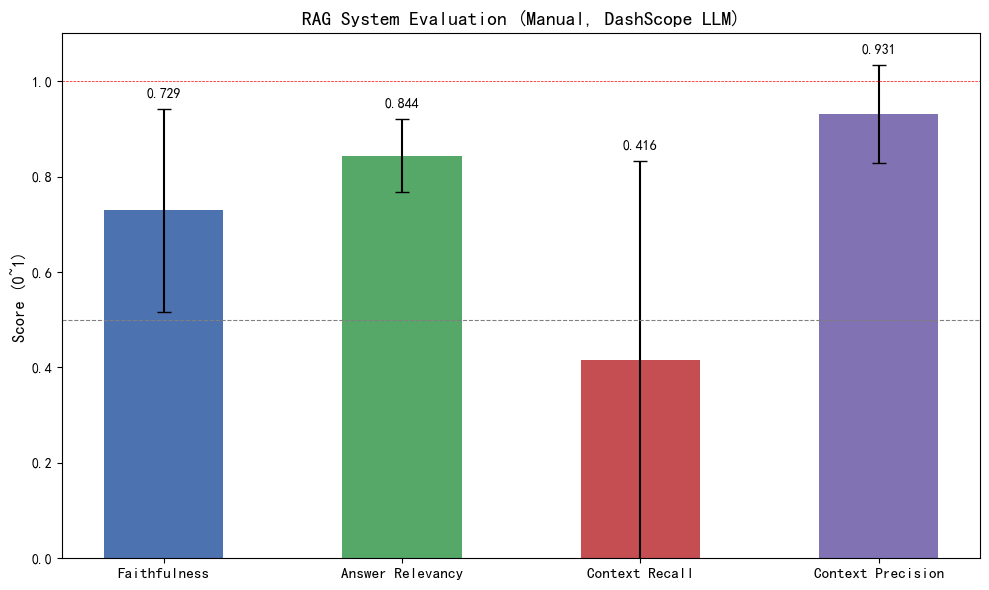

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
labels = ["Faithfulness", "Answer Relevancy", "Context Recall", "Context Precision"]

means = []
stds = []
for m in metrics:
    vals = result_df[m].dropna()
    means.append(vals.mean())
    stds.append(vals.std())

x = range(len(labels))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, means, 0.5, yerr=stds, capsize=5,
              color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])

ax.set_ylabel("Score (0~1)", fontsize=12)
ax.set_title("RAG System Evaluation (Manual, DashScope LLM)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.axhline(1, color="red", linestyle="--", linewidth=0.5)

for bar, mean_val, std_val in zip(bars, means, stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + std_val + 0.02,
            f"{mean_val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()